# Test Sparse Neural Network - Sparsity Maintenance During Training

This notebook tests that the sparse neural network maintains sparsity during training.


In [1]:
import sys
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "19"

sys.path.insert(0, os.path.dirname(os.path.abspath('')))  # Add current directory to path

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sparse_nn import Sparse_NN

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")


/homes/jchia/miniconda3/envs/cuda11_env/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 1.8.0
CUDA available: True


## 1. Create Sparse Neural Network


In [15]:
seed = 42
genotype_hiddens = 4

model = Sparse_NN(
    input_dim=689,
    dropout_fraction=0.0,
    activation=nn.ReLU,
    genotype_hiddens=genotype_hiddens,
    seed=seed
)

print(f"Model created with {model.num_attempts} attempts")
print(f"Number of layers: {len(model.connectivity_list)}")


✓ Successfully generated valid network after 137 attempts
Model created with 137 attempts
Number of layers: 8


## 2. Count Initial Non-Zero Weights


In [6]:
def count_nonzero_weights(model):
    """Count non-zero weights in all linear layers."""
    total_params = 0
    nonzero_params = 0
    layer_stats = []
    
    layer_idx = 0
    for module in model.NN:
        if isinstance(module, nn.Linear):
            weight = module.weight.data
            total = weight.numel()
            nonzero = weight.nonzero().size(0)
            
            total_params += total
            nonzero_params += nonzero
            
            # Check if layer has bias
            bias_info = ""
            if module.bias is not None:
                bias_total = module.bias.data.numel()
                bias_nonzero = module.bias.data.nonzero().size(0)
                bias_info = f", bias: {bias_nonzero}/{bias_total} nonzero"
            
            layer_stats.append({
                'layer': layer_idx,
                'shape': tuple(weight.shape),
                'total': total,
                'nonzero': nonzero,
                'sparsity': 1.0 - (nonzero / total),
                'bias_info': bias_info
            })
            
            print(f"Layer {layer_idx} (shape {weight.shape}): {nonzero}/{total} nonzero ({100*(1-nonzero/total):.2f}% sparse){bias_info}")
            layer_idx += 1
    
    return total_params, nonzero_params, layer_stats

print("=== Initial Weight Statistics ===")
initial_total, initial_nonzero, initial_stats = count_nonzero_weights(model)
print(f"\nTotal weights: {initial_total:,}")
print(f"Non-zero weights: {initial_nonzero:,}")
print(f"Overall sparsity: {100*(1-initial_nonzero/initial_total):.2f}%")


=== Initial Weight Statistics ===
Layer 0 (shape torch.Size([304, 689])): 5284/209456 nonzero (97.48% sparse), bias: 304/304 nonzero
Layer 1 (shape torch.Size([128, 304])): 1472/38912 nonzero (96.22% sparse), bias: 128/128 nonzero
Layer 2 (shape torch.Size([52, 128])): 576/6656 nonzero (91.35% sparse), bias: 52/52 nonzero
Layer 3 (shape torch.Size([16, 52])): 208/832 nonzero (75.00% sparse), bias: 16/16 nonzero
Layer 4 (shape torch.Size([8, 16])): 64/128 nonzero (50.00% sparse), bias: 8/8 nonzero
Layer 5 (shape torch.Size([8, 8])): 32/64 nonzero (50.00% sparse), bias: 8/8 nonzero
Layer 6 (shape torch.Size([4, 8])): 32/32 nonzero (0.00% sparse), bias: 4/4 nonzero
Layer 7 (shape torch.Size([4, 4])): 16/16 nonzero (0.00% sparse), bias: 4/4 nonzero
Layer 8 (shape torch.Size([1, 4])): 4/4 nonzero (0.00% sparse), bias: 1/1 nonzero

Total weights: 256,100
Non-zero weights: 7,688
Overall sparsity: 97.00%


## 2.5. Verify Edge Counts Match nest_edges_by_layer


In [ ]:
print("=== Verifying Edge Counts Match nest_edges_by_layer ===")
print(f"{'Layer':<10} {'Expected (nest_edges)':<25} {'Actual (non-zero)':<25} {'Match':<10}")
print("-" * 75)

all_match = True
layer_idx = 0
for module in model.NN:
    if isinstance(module, nn.Linear):
        # Skip the final output layer (it's not in nest_edges_by_layer)
        if layer_idx >= len(model.nest_edges_by_layer):
            break
        
        # Get expected number of edges
        expected_edges = model.nest_edges_by_layer[layer_idx]
        
        # Count actual non-zero weights
        weight = module.weight.data
        actual_edges = weight.nonzero().size(0)
        
        # Also check mask if available
        if hasattr(module, 'weight_mask'):
            mask_edges = module.weight_mask.sum().item()
            if mask_edges != actual_edges:
                print(f"⚠️  Layer {layer_idx}: Mask has {mask_edges} edges but weights have {actual_edges} non-zero")
        
        match = "✓" if actual_edges == expected_edges else "❌"
        if actual_edges != expected_edges:
            all_match = False
        
        print(f"{match} Layer {layer_idx:<7} {expected_edges:<25} {actual_edges:<25} {match:<10}")
        layer_idx += 1

print("-" * 75)
if all_match:
    print("✅ SUCCESS: All layers have the correct number of edges matching nest_edges_by_layer!")
else:
    print("❌ ERROR: Some layers do not match nest_edges_by_layer!")


=== Verifying Edge Counts Match nest_edges_by_layer ===
Layer      Expected (nest_edges)     Actual (non-zero)         Match     
---------------------------------------------------------------------------
✓ Layer 0       5284                      5284                      ✓         
✓ Layer 1       1472                      1472                      ✓         
✓ Layer 2       576                       576                       ✓         
✓ Layer 3       208                       208                       ✓         
✓ Layer 4       64                        64                        ✓         
✓ Layer 5       32                        32                        ✓         
✓ Layer 6       32                        32                        ✓         
✓ Layer 7       16                        16                        ✓         
---------------------------------------------------------------------------
✅ SUCCESS: All layers have the correct number of edges matching nest_edges_by_layer!


## 3. Verify Masks Are Applied


In [ ]:
print("=== Checking Pruning Masks ===")
layer_idx = 0
for module in model.NN:
    if isinstance(module, nn.Linear):
        if hasattr(module, 'weight_mask'):
            mask = module.weight_mask
            weight = module.weight.data
            
            # Check that masked weights are actually zero
            masked_weights = weight * mask
            actual_nonzero = masked_weights.nonzero().size(0)
            expected_nonzero = mask.sum().item()
            
            print(f"Layer {layer_idx}: mask has {expected_nonzero} ones, "
                  f"masked weights have {actual_nonzero} non-zero values")
            
            if actual_nonzero != expected_nonzero:
                print(f"  ⚠️  WARNING: Mismatch! Some masked weights are non-zero")
            else:
                print(f"  ✓ Mask correctly applied")
        else:
            print(f"Layer {layer_idx}: No weight_mask found (this is the final output layer)")
        layer_idx += 1


=== Checking Pruning Masks ===
Layer 0: mask has 5284.0 ones, masked weights have 5284 non-zero values
  ✓ Mask correctly applied
Layer 1: mask has 1472.0 ones, masked weights have 1472 non-zero values
  ✓ Mask correctly applied
Layer 2: mask has 576.0 ones, masked weights have 576 non-zero values
  ✓ Mask correctly applied
Layer 3: mask has 208.0 ones, masked weights have 208 non-zero values
  ✓ Mask correctly applied
Layer 4: mask has 64.0 ones, masked weights have 64 non-zero values
  ✓ Mask correctly applied
Layer 5: mask has 32.0 ones, masked weights have 32 non-zero values
  ✓ Mask correctly applied
Layer 6: mask has 32.0 ones, masked weights have 32 non-zero values
  ✓ Mask correctly applied
Layer 7: mask has 16.0 ones, masked weights have 16 non-zero values
  ✓ Mask correctly applied
Layer 8: No weight_mask found (this is the final output layer)


## 4. Create Dummy Training Data


In [ ]:
batch_size = 32
num_samples = 1000

# Generate dummy data
torch.manual_seed(123)
X_train = torch.randn(num_samples, 689)
# Create dummy binary labels
y_train = torch.randint(0, 2, (num_samples, 1)).float()

print(f"Training data shape: {X_train.shape}")
print(f"Labels shape: {y_train.shape}")
print(f"Number of batches: {len(X_train) // batch_size}")


Training data shape: torch.Size([1000, 689])
Labels shape: torch.Size([1000, 1])
Number of batches: 31


## 5. Train Model for Several Iterations


In [ ]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 5
losses = []
sparsity_history = []

print(f"Training for {num_epochs} epochs...")
print("=" * 60)

for epoch in range(num_epochs):
    epoch_losses = []
    
    # Mini-batch training
    for i in range(0, len(X_train), batch_size):
        batch_X = X_train[i:i+batch_size]
        batch_y = y_train[i:i+batch_size]
        
        optimizer.zero_grad()
        output = model(batch_X)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        
        epoch_losses.append(loss.item())
    
    avg_loss = np.mean(epoch_losses)
    losses.append(avg_loss)
    
    # Count non-zero weights after this epoch
    _, nonzero, _ = count_nonzero_weights(model)
    sparsity = 1.0 - (nonzero / initial_total)
    sparsity_history.append(sparsity)
    
    print(f"Epoch {epoch+1}/{num_epochs}: Loss = {avg_loss:.4f}, "
          f"Non-zero weights = {nonzero:,}, Sparsity = {100*sparsity:.2f}%")

print("=" * 60)
print("Training complete!")


Training for 5 epochs...
Layer 0 (shape torch.Size([304, 689])): 5284/209456 nonzero (97.48% sparse), bias: 304/304 nonzero
Layer 1 (shape torch.Size([128, 304])): 1472/38912 nonzero (96.22% sparse), bias: 128/128 nonzero
Layer 2 (shape torch.Size([52, 128])): 576/6656 nonzero (91.35% sparse), bias: 52/52 nonzero
Layer 3 (shape torch.Size([16, 52])): 208/832 nonzero (75.00% sparse), bias: 16/16 nonzero
Layer 4 (shape torch.Size([8, 16])): 64/128 nonzero (50.00% sparse), bias: 8/8 nonzero
Layer 5 (shape torch.Size([8, 8])): 32/64 nonzero (50.00% sparse), bias: 8/8 nonzero
Layer 6 (shape torch.Size([4, 8])): 32/32 nonzero (0.00% sparse), bias: 4/4 nonzero
Layer 7 (shape torch.Size([4, 4])): 16/16 nonzero (0.00% sparse), bias: 4/4 nonzero
Layer 8 (shape torch.Size([1, 4])): 4/4 nonzero (0.00% sparse), bias: 1/1 nonzero
Epoch 1/5: Loss = 0.2506, Non-zero weights = 7,688, Sparsity = 97.00%
Layer 0 (shape torch.Size([304, 689])): 5284/209456 nonzero (97.48% sparse), bias: 304/304 nonzero
Lay

## 6. Final Weight Statistics


In [ ]:
print("=== Final Weight Statistics ===")
final_total, final_nonzero, final_stats = count_nonzero_weights(model)
print(f"\nTotal weights: {final_total:,}")
print(f"Non-zero weights: {final_nonzero:,}")
print(f"Overall sparsity: {100*(1-final_nonzero/final_total):.2f}%")

print("\n=== Comparison ===")
print(f"Initial non-zero weights: {initial_nonzero:,}")
print(f"Final non-zero weights: {final_nonzero:,}")
print(f"Difference: {final_nonzero - initial_nonzero:,}")

if final_nonzero == initial_nonzero:
    print("\n✅ SUCCESS: Sparsity maintained perfectly!")
elif abs(final_nonzero - initial_nonzero) < 10:
    print(f"\n⚠️  WARNING: Small change in sparsity ({final_nonzero - initial_nonzero} weights)")
else:
    print(f"\n❌ ERROR: Significant change in sparsity!")
    print(f"   This suggests masks are not being maintained properly.")


=== Final Weight Statistics ===
Layer 0 (shape torch.Size([304, 689])): 5284/209456 nonzero (97.48% sparse), bias: 304/304 nonzero
Layer 1 (shape torch.Size([128, 304])): 1472/38912 nonzero (96.22% sparse), bias: 128/128 nonzero
Layer 2 (shape torch.Size([52, 128])): 576/6656 nonzero (91.35% sparse), bias: 52/52 nonzero
Layer 3 (shape torch.Size([16, 52])): 208/832 nonzero (75.00% sparse), bias: 16/16 nonzero
Layer 4 (shape torch.Size([8, 16])): 64/128 nonzero (50.00% sparse), bias: 8/8 nonzero
Layer 5 (shape torch.Size([8, 8])): 32/64 nonzero (50.00% sparse), bias: 8/8 nonzero
Layer 6 (shape torch.Size([4, 8])): 32/32 nonzero (0.00% sparse), bias: 4/4 nonzero
Layer 7 (shape torch.Size([4, 4])): 16/16 nonzero (0.00% sparse), bias: 4/4 nonzero
Layer 8 (shape torch.Size([1, 4])): 4/4 nonzero (0.00% sparse), bias: 1/1 nonzero

Total weights: 256,100
Non-zero weights: 7,688
Overall sparsity: 97.00%

=== Comparison ===
Initial non-zero weights: 7,688
Final non-zero weights: 7,688
Difference

## 7. Verify Masks Are Still Applied After Training


In [ ]:
print("=== Verifying Masks After Training ===")
layer_idx = 0
all_masks_valid = True

for module in model.NN:
    if isinstance(module, nn.Linear):
        if hasattr(module, 'weight_mask'):
            mask = module.weight_mask
            weight = module.weight.data
            
            # Check that weights respect the mask
            # All weights where mask is 0 should be 0
            masked_out = weight * (1 - mask)  # Weights where mask is 0
            nonzero_masked_out = masked_out.nonzero().size(0)
            
            if nonzero_masked_out > 0:
                print(f"❌ Layer {layer_idx}: {nonzero_masked_out} weights are non-zero where mask is 0!")
                all_masks_valid = False
            else:
                print(f"✓ Layer {layer_idx}: All masked-out weights are zero")
        layer_idx += 1

if all_masks_valid:
    print("\n✅ All masks are correctly maintained!")
else:
    print("\n❌ Some masks are not being maintained properly!")


=== Verifying Masks After Training ===
✓ Layer 0: All masked-out weights are zero
✓ Layer 1: All masked-out weights are zero
✓ Layer 2: All masked-out weights are zero
✓ Layer 3: All masked-out weights are zero
✓ Layer 4: All masked-out weights are zero
✓ Layer 5: All masked-out weights are zero
✓ Layer 6: All masked-out weights are zero
✓ Layer 7: All masked-out weights are zero

✅ All masks are correctly maintained!


## 8. Visualize Training Progress


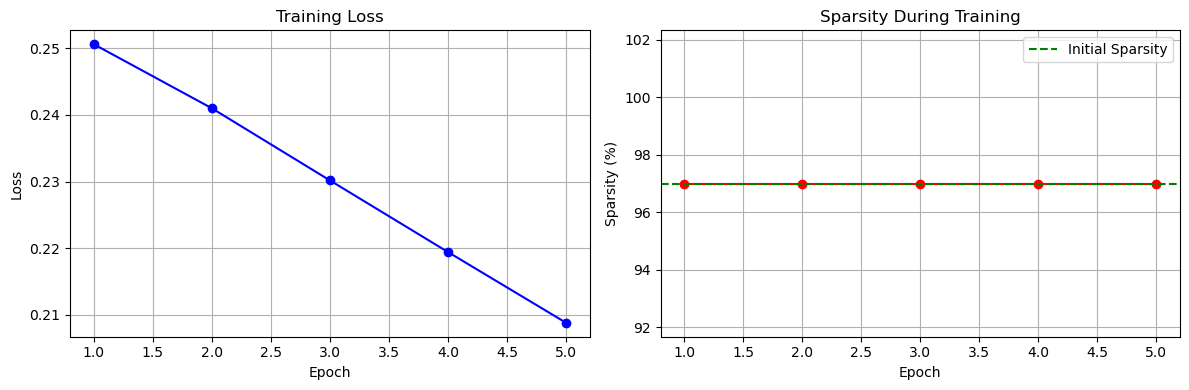

Initial sparsity: 97.00%
Final sparsity: 97.00%


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot loss
ax1.plot(range(1, num_epochs + 1), losses, 'b-', marker='o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.grid(True)

# Plot sparsity
ax2.plot(range(1, num_epochs + 1), [s * 100 for s in sparsity_history], 'r-', marker='o')
ax2.axhline(y=100*(1-initial_nonzero/initial_total), color='g', linestyle='--', label='Initial Sparsity')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Sparsity (%)')
ax2.set_title('Sparsity During Training')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"Initial sparsity: {100*(1-initial_nonzero/initial_total):.2f}%")
print(f"Final sparsity: {100*(1-final_nonzero/final_total):.2f}%")


## 9. Layer-by-Layer Comparison


In [22]:
print("=== Layer-by-Layer Comparison ===")
print(f"{'Layer':<10} {'Initial Non-Zero':<20} {'Final Non-Zero':<20} {'Change':<10}")
print("-" * 70)

for init_stat, final_stat in zip(initial_stats, final_stats):
    change = final_stat['nonzero'] - init_stat['nonzero']
    status = "✓" if change == 0 else "⚠️"
    print(f"{status} Layer {init_stat['layer']:<7} {init_stat['nonzero']:<20} {final_stat['nonzero']:<20} {change:<10}")


=== Layer-by-Layer Comparison ===
Layer      Initial Non-Zero     Final Non-Zero       Change    
----------------------------------------------------------------------
✓ Layer 0       5284                 5284                 0         
✓ Layer 1       1472                 1472                 0         
✓ Layer 2       576                  576                  0         
✓ Layer 3       208                  208                  0         
✓ Layer 4       64                   64                   0         
✓ Layer 5       32                   32                   0         
✓ Layer 6       32                   32                   0         
✓ Layer 7       16                   16                   0         
✓ Layer 8       4                    4                    0         
